# Analysing the SEF output

This notebook produces summary figures from the final deliverable of the
pipeline -- the exported [Station Exchange Format](https://datarescue.climate.copernicus.eu/station-exchange-format-sef)
(SEF) `.tsv` files. Its purpose is to show the shared data is **useful** and to
surface **hidden bugs** before shipping.

Every figure is computed **only from the SEF files** (nothing from the working
databases). Reading the raw `.tsv` tree for each figure would be slow, so the SEF
files are first parsed **once** into a compact Parquet analysis dataset
(`observations` + precomputed `daily_national` aggregates) that this notebook
then queries cheaply with DuckDB. Build that dataset in parallel on SLURM with
`scripts/slurm/submit_sef_analysis.sh` (one array task per SEF year).

> **Coverage caveat.** The station network grows enormously over the record
> (from a handful of gauges in the 18th century to thousands by the 1930s). The
> national series below are simple **means over the reporting stations** each
> day/year, so *absolute* levels and trends are influenced by which stations
> exist -- treat between-era comparisons with care. Where a metric is sensitive
> to coverage (e.g. extreme counts) it is shown as a **rate per reporting
> station**.

## How the analysis dataset is built

| Stage | Script | SLURM | Purpose |
|-------|--------|-------|---------|
| convert | `scripts/build_sef_analysis_parquet.py` | array `0-(Y-1)` | parse each SEF year into `observations/` + `daily_national/` Parquet |

There is **no merge stage**: every date belongs to exactly one year, so each
task writes disjoint `year=<Y>.parquet` files. Configuration lives in
`scripts/slurm/config.sh` under the `SEFSTATS_*` variables; the prerequisite is
the SEF export itself (`submit_sef_export.sh`). Everything lands under
`$PDIR/sef_analysis/`.

## Setup

In [17]:
import os
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Show every row of the annual summary tables (they have ~100 years).
pd.set_option("display.max_rows", None)

# Make the repository importable (the notebook runs from notebooks/).
repo_root = Path.cwd()
while not (repo_root / "src").is_dir() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.rainfall_rescue_sqlite.sef_analysis import (
    WET_THRESHOLD_MM,
    EXTREME_THRESHOLDS_MM,
    build_year_parquet,
    default_analysis_root,
    default_sef_root,
    discover_years,
)

os.environ.setdefault("PDIR", "/data/scratch/philip.brohan/ADRQ")
sef_root = default_sef_root()
analysis_root = default_analysis_root()
print(f"SEF export root: {sef_root}")
print(f"Analysis root:   {analysis_root}")
print(f"Extreme thresholds (mm): {EXTREME_THRESHOLDS_MM};  wet-day threshold: {WET_THRESHOLD_MM} mm")

SEF export root: /data/scratch/philip.brohan/ADRQ/sef_export
Analysis root:   /data/scratch/philip.brohan/ADRQ/sef_analysis
Extreme thresholds (mm): (10.0, 25.0, 50.0);  wet-day threshold: 1.0 mm


### Locate (or build a demo of) the analysis dataset

If the operational Parquet dataset does not exist yet, a small demo is built
locally into `/var/tmp` from a few SEF years so the notebook is self-contained.
For the full record, run `scripts/slurm/submit_sef_analysis.sh` first and re-run
this cell.

The analysis is limited to a year range (`YEAR_MIN`–`YEAR_MAX`, default
**1860–1960**). The dataset targets that span; a few stray stations outside it
have poor QC whose errors dominate the variability, so they are excluded by
default. Change the range and re-run from this cell down to widen the window.


In [13]:
DEMO_YEARS = [1903, 1921, 1931]  # a wet year, a drought year, and the busiest year

# Restrict every figure below to this inclusive year range. The dataset targets
# 1860-1960; a handful of stray stations outside it have poor QC and their errors
# dominate the variability, so they are excluded by default. Widen if you want to
# inspect them, then re-run from this cell down.
YEAR_MIN, YEAR_MAX = 1860, 1960

# Re-check the operational root freshly each run (don't rely on `analysis_root`,
# which this cell reassigns to the demo path when no operational data exists).
operational_root = default_analysis_root()
obs_dir = operational_root / "observations"
have_operational = obs_dir.is_dir() and any(obs_dir.glob("*.parquet"))

if have_operational:
    analysis_root = operational_root
    print(f"Using operational SEF analysis parquet at {analysis_root}")
else:
    print("No operational SEF analysis parquet found; building a local demo ...")
    analysis_root = Path("/var/tmp/sef_analysis_demo")
    available = set(discover_years(sef_root))
    for year in DEMO_YEARS:
        if year not in available:
            print(f"  (SEF year {year} not present in the export; skipping)")
            continue
        out = analysis_root / "observations" / f"year={year}.parquet"
        if out.exists():
            print(f"  {year}: already built")
            continue
        summary = build_year_parquet(sef_root, year, analysis_root)
        print(f"  {year}: {summary['n_observations']} obs, {summary['n_passed']} passed")


def _parquet_sources(table: str) -> str:
    # DuckDB list literal of the year=<Y>.parquet files within [YEAR_MIN, YEAR_MAX].
    # Limiting the files read at the source restricts every query and plot below.
    directory = Path(analysis_root) / table
    files = [
        str(directory / f"year={year}.parquet")
        for year in range(YEAR_MIN, YEAR_MAX + 1)
        if (directory / f"year={year}.parquet").exists()
    ]
    if not files:
        raise FileNotFoundError(
            f"No {table} parquet for years {YEAR_MIN}-{YEAR_MAX} under {directory}"
        )
    return "[" + ", ".join(f"'{f}'" for f in files) + "]"


daily_src = _parquet_sources("daily_national")
obs_src = _parquet_sources("observations")
con = duckdb.connect()


def q(sql: str) -> pd.DataFrame:
    # Run a DuckDB query; {daily} and {obs} expand to the in-range parquet file lists.
    return con.execute(sql.format(daily=daily_src, obs=obs_src)).df()


years_present = q("SELECT DISTINCT year FROM read_parquet({daily}) ORDER BY year")["year"].tolist()
print(f"Analysis root in use: {analysis_root}")
print(f"Year range examined:  {YEAR_MIN}-{YEAR_MAX}")
print(f"Years with data:      {len(years_present)} ({min(years_present)}-{max(years_present)})")


Using operational SEF analysis parquet at /data/scratch/philip.brohan/ADRQ/sef_analysis
Analysis root in use: /data/scratch/philip.brohan/ADRQ/sef_analysis
Year range examined:  1860-1960
Years with data:      101 (1860-1960)


## 1. Observation coverage

How many stations report, how many observations they contribute, and what
fraction meet the QC criteria to be trusted (`qc1 == pass` or `qc2` was not a
definitive fail). A healthy export should pass the great majority of
observations; a sudden dip would point to a QC or export bug.

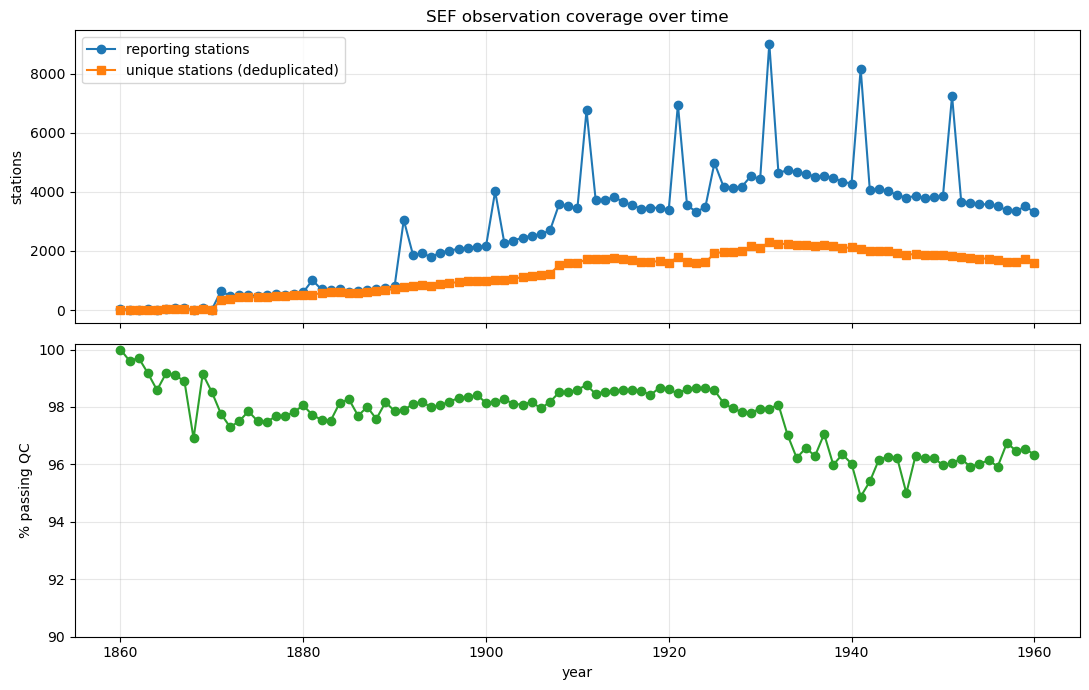

,year,n_obs,n_stations,n_unique_stations,pct_passed
0,1860,10614,29,3,100.00
1,1861,5840,16,7,99.61
2,1862,4380,12,7,99.70
3,1863,7665,21,7,99.18
4,1864,4392,12,10,98.59
5,1865,11680,32,19,99.18
6,1866,25915,71,42,99.10
7,1867,20075,55,43,98.90
8,1868,2196,6,6,96.90
9,1869,23360,64,44,99.15


In [19]:
coverage = q('''
    SELECT year,
        count(*) AS n_obs,
        count(DISTINCT station_id) AS n_stations,
        count(DISTINCT (latitude || ',' || longitude)) AS n_unique_stations,
        100.0 * sum(passed::int) / count(*) AS pct_passed
    FROM read_parquet({obs})
    GROUP BY year ORDER BY year
''')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.plot(coverage["year"], coverage["n_stations"], "-o", color="#1f77b4",
         label="reporting stations")
ax1.plot(coverage["year"], coverage["n_unique_stations"], "-s", color="#ff7f0e",
         label="unique stations (deduplicated)")
ax1.set_ylabel("stations")
ax1.set_title("SEF observation coverage over time")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(coverage["year"], coverage["pct_passed"], "-o", color="#2ca02c")
ax2.set_ylabel("% passing QC")
ax2.set_xlabel("year")
ax2.set_ylim(min(90, coverage["pct_passed"].min() - 1), 100.2)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

coverage.assign(pct_passed=coverage["pct_passed"].round(2))


## 2. Trends in rainfall

National-mean daily rainfall (mean over reporting stations) aggregated to an
annual total. *Absolute levels are coverage-influenced (see the caveat above);
this is most useful as a check that year-to-year variability looks physical and
that no year is wildly out of range.*

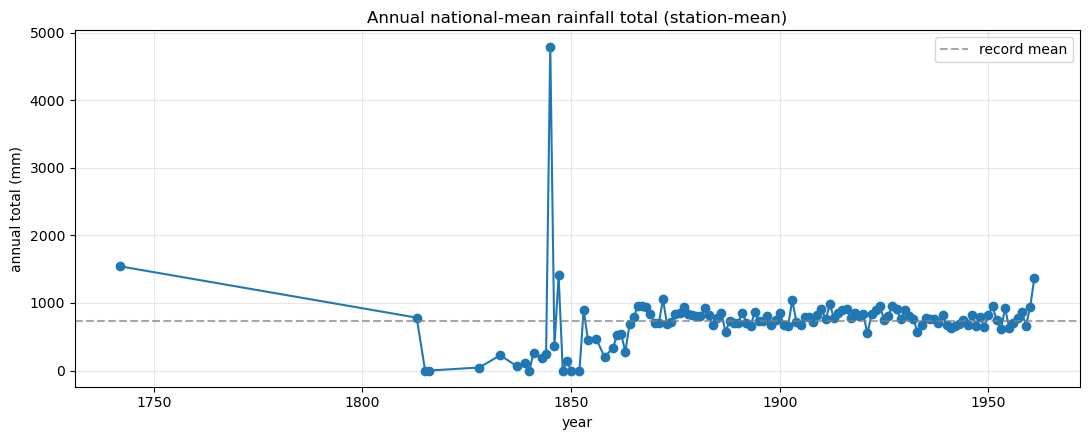

,year,mean_daily_mm,annual_total_mm,station_days
0,1742,4.221,1540.7,365.0
1,1813,2.142,781.9,365.0
2,1815,0.000,0.0,730.0
3,1816,0.000,0.0,732.0
4,1828,0.122,44.6,732.0
...,...,...,...,...
120,1957,2.118,773.0,1192857.0
121,1958,2.389,871.8,1176171.0
122,1959,1.820,664.1,1241039.0
123,1960,2.557,936.0,1166120.0


In [7]:
annual = q('''
    SELECT year,
        avg(mean_mm) AS mean_daily_mm,
        sum(mean_mm) AS annual_total_mm,
        sum(n_stations_reporting) AS station_days
    FROM read_parquet({daily})
    GROUP BY year ORDER BY year
''')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(annual["year"], annual["annual_total_mm"], "-o", color="#1f77b4")
if len(annual) > 1:
    ax.axhline(annual["annual_total_mm"].mean(), ls="--", color="grey", alpha=0.7,
               label="record mean")
    ax.legend()
ax.set_title("Annual national-mean rainfall total (station-mean)")
ax.set_ylabel("annual total (mm)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

annual.assign(annual_total_mm=annual["annual_total_mm"].round(1),
              mean_daily_mm=annual["mean_daily_mm"].round(3))

## 3. Trends in rainfall intensity

Two coverage-robust intensity measures, computed per year over the trusted
observations:

* **SDII** (Simple Daily Intensity Index) -- the mean rainfall on *wet* days
  (>= 1 mm). Independent of how many dry days or stations there are.
* **Wet-day fraction** -- the share of station-days that are wet.

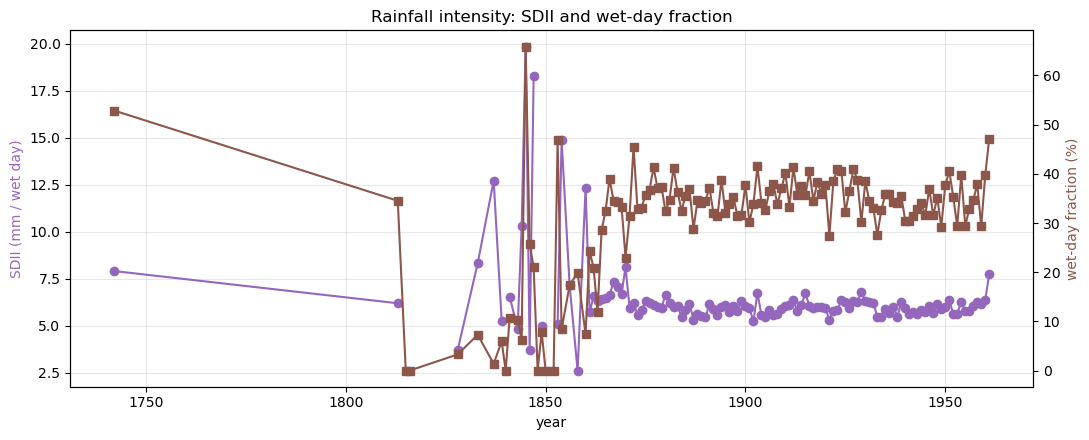

,year,sdii_mm,wet_fraction
0,1742,7.91,52.9
1,1813,6.20,34.5
2,1815,NaN,0.0
3,1816,NaN,0.0
4,1828,3.72,3.3
...,...,...,...
120,1957,6.05,34.6
121,1958,6.24,38.0
122,1959,6.13,29.3
123,1960,6.38,39.7


In [8]:
intensity = q('''
    SELECT year,
        avg(value_mm) FILTER (WHERE passed AND value_mm >= {wet}) AS sdii_mm,
        avg((passed AND value_mm >= {wet})::int)
            FILTER (WHERE passed AND value_mm IS NOT NULL) AS wet_fraction
    FROM read_parquet({{obs}})
    GROUP BY year ORDER BY year
'''.format(wet=WET_THRESHOLD_MM))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(intensity["year"], intensity["sdii_mm"], "-o", color="#9467bd", label="SDII (mean wet-day mm)")
ax.set_ylabel("SDII (mm / wet day)", color="#9467bd")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
axb = ax.twinx()
axb.plot(intensity["year"], 100 * intensity["wet_fraction"], "-s", color="#8c564b",
         label="wet-day %")
axb.set_ylabel("wet-day fraction (%)", color="#8c564b")
ax.set_title("Rainfall intensity: SDII and wet-day fraction")
plt.tight_layout()
plt.show()

intensity.assign(sdii_mm=intensity["sdii_mm"].round(2),
                 wet_fraction=(100 * intensity["wet_fraction"]).round(1))

## 4. Wettest days

The wettest days by **national mean** rainfall (a widespread soaking), and the
most extreme individual **station-days** (a single very large gauge reading --
also a useful place to look for transcription/units bugs).

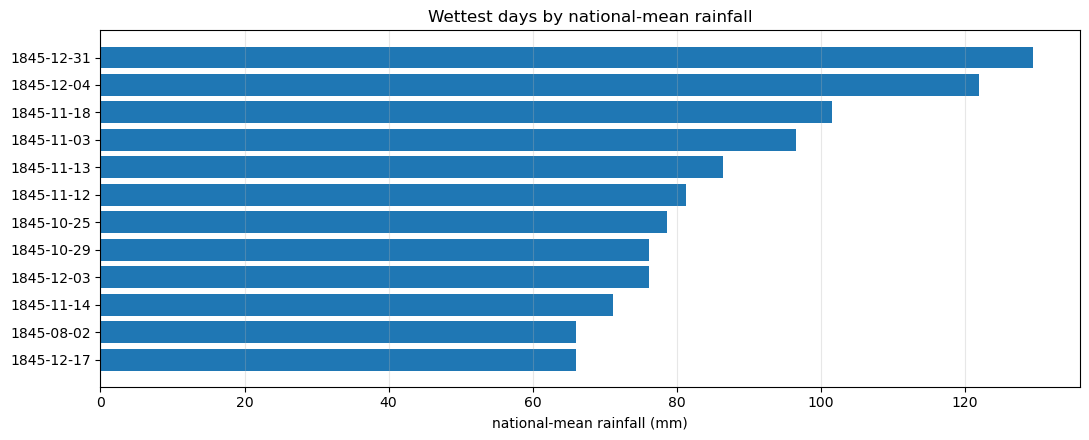

Most extreme individual station-days:


,obs_date,station_id,location_name,value_mm,lat,lon
0,1955-08-28,DRain_1951-1962_RainNos_2954-2988-83,LOCH EIL (ACHOLALIEU),551.2,56.857,-5.189
1,1955-08-28,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH EIL (ACHOLALIEU),551.2,56.857,-5.189
2,1951-02-28,DRain_1951-1962_RainNos_4337-4375_B037-1,LLANBEDR-Y-CENNIN LLYNDULYN,520.7,53.179,-3.937
3,1936-12-31,DRain_1931-1940_RainNos_4328-4360-354,LAKE-COWLYD-FFRITH-GARREG-WEN,469.9,53.153,-3.887
4,1936-12-31,DRain_1931-1940_RainNos_4328-4360_B042-6,LAKE-COWLYD-FFRITH-GARREG-WEN,469.9,53.153,-3.887
5,1955-10-19,DRain_1951-1962_RainNos_2954-2988-83,LOCH EIL (ACHOLALIEU),442.0,56.857,-5.189
6,1955-10-19,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH EIL (ACHOLALIEU),442.0,56.857,-5.189
7,1936-12-31,DRain_1931-1940_RainNos_4328-4360-365,LAKE-COWLYD-FFRITH-FAWR-B,431.8,53.145,-3.912
8,1955-01-25,DRain_1951-1962_RainNos_2954-2988-83,LOCH EIL (ACHOLALIEU),388.6,56.857,-5.189
9,1955-01-25,DRain_1951-1962_RainNos_2954-2988_B045-13,LOCH EIL (ACHOLALIEU),388.6,56.857,-5.189


In [9]:
wettest_national = q('''
    SELECT obs_date, n_stations_reporting,
        round(mean_mm, 2) AS mean_mm, round(max_mm, 1) AS max_mm, argmax_location
    FROM read_parquet({daily})
    ORDER BY mean_mm DESC LIMIT 12
''')

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = wettest_national["obs_date"].astype(str)
ax.barh(labels[::-1], wettest_national["mean_mm"][::-1], color="#1f77b4")
ax.set_xlabel("national-mean rainfall (mm)")
ax.set_title("Wettest days by national-mean rainfall")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("Most extreme individual station-days:")
q('''
    SELECT obs_date, station_id, location_name, round(value_mm, 1) AS value_mm,
        round(latitude, 3) AS lat, round(longitude, 3) AS lon
    FROM read_parquet({obs})
    WHERE passed AND value_mm IS NOT NULL
    ORDER BY value_mm DESC LIMIT 12
''')

## 5. Extreme rainfall frequency

How often heavy-rain days occur, shown as a **rate per 1000 reporting
station-days** so it is not simply tracking the growing network. Thresholds are
the `EXTREME_THRESHOLDS_MM` used when the dataset was built.

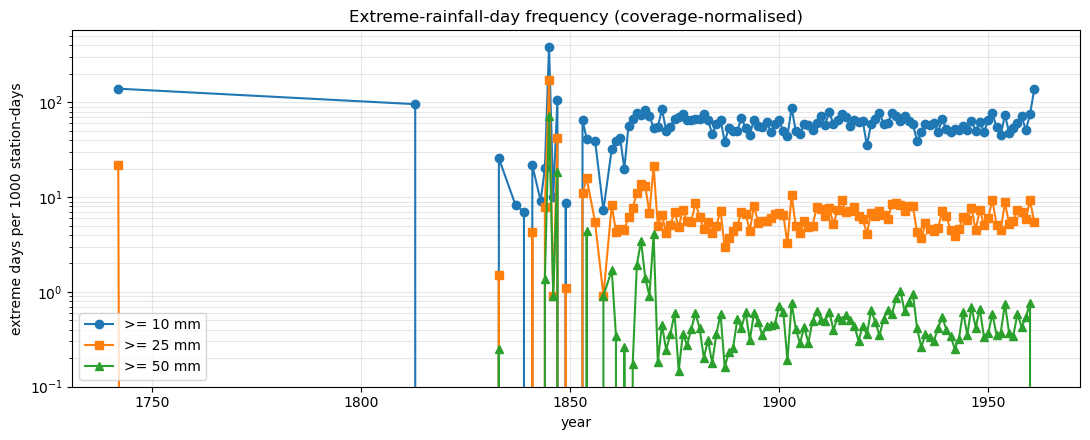

,year,ge10_rate,ge25_rate,ge50_rate
0,1742,139.726,21.918,0.000
1,1813,95.890,0.000,0.000
2,1815,0.000,0.000,0.000
3,1816,0.000,0.000,0.000
4,1828,0.000,0.000,0.000
...,...,...,...,...
120,1957,60.519,7.355,0.587
121,1958,71.339,7.037,0.425
122,1959,51.089,5.906,0.537
123,1960,74.676,9.237,0.771


In [10]:
ge10, ge25, ge50 = EXTREME_THRESHOLDS_MM
extremes = q('''
    SELECT year,
        1000.0 * sum(n_ge10) / sum(n_stations_reporting) AS ge10_rate,
        1000.0 * sum(n_ge25) / sum(n_stations_reporting) AS ge25_rate,
        1000.0 * sum(n_ge50) / sum(n_stations_reporting) AS ge50_rate
    FROM read_parquet({daily})
    GROUP BY year ORDER BY year
''')

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(extremes["year"], extremes["ge10_rate"], "-o", label=f">= {ge10:.0f} mm")
ax.plot(extremes["year"], extremes["ge25_rate"], "-s", label=f">= {ge25:.0f} mm")
ax.plot(extremes["year"], extremes["ge50_rate"], "-^", label=f">= {ge50:.0f} mm")
ax.set_yscale("log")
ax.set_ylabel("extreme days per 1000 station-days")
ax.set_xlabel("year")
ax.set_title("Extreme-rainfall-day frequency (coverage-normalised)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

extremes.round(3)

## 6. Known historical events

A quick cross-check against documented UK rainfall history. If the SEF data is
faithful, well-known **floods** should coincide with wet extremes and
**droughts** with dry years. The events below are annotated on the annual-mean
series; where the event's year is in the loaded data a SEF-derived daily map is
drawn.

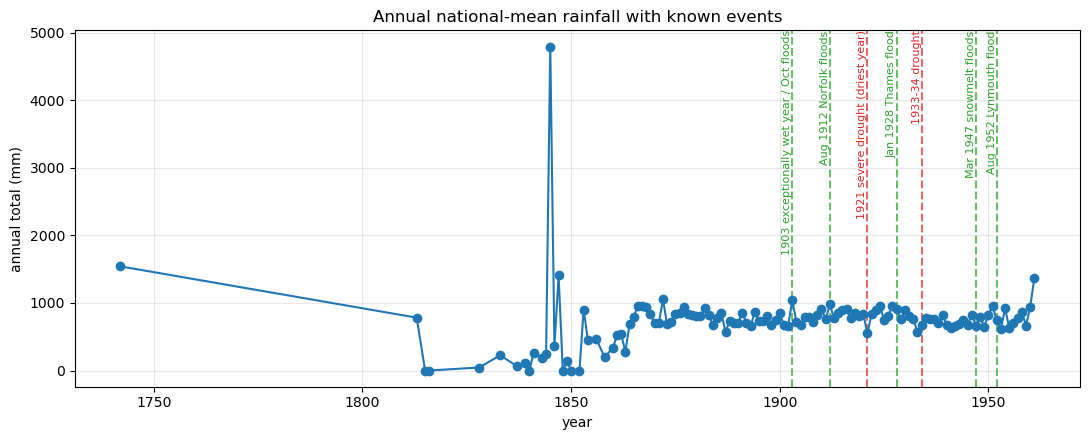

Events within the loaded record:
  1903-10-27  flood     1903 exceptionally wet year / Oct floods
  1912-08-26  flood     Aug 1912 Norfolk floods
  1921-07-01  drought   1921 severe drought (driest year)
  1928-01-07  flood     Jan 1928 Thames flood
  1934-01-01  drought   1933-34 drought
  1947-03-16  flood     Mar 1947 snowmelt floods
  1952-08-15  flood     Aug 1952 Lynmouth flood


In [11]:
# Curated major UK rainfall events (date used for the event map; year for annotation).
EVENTS = [
    {"date": "1903-10-27", "year": 1903, "kind": "flood",
     "label": "1903 exceptionally wet year / Oct floods"},
    {"date": "1912-08-26", "year": 1912, "kind": "flood",
     "label": "Aug 1912 Norfolk floods"},
    {"date": "1921-07-01", "year": 1921, "kind": "drought",
     "label": "1921 severe drought (driest year)"},
    {"date": "1928-01-07", "year": 1928, "kind": "flood",
     "label": "Jan 1928 Thames flood"},
    {"date": "1934-01-01", "year": 1934, "kind": "drought",
     "label": "1933-34 drought"},
    {"date": "1947-03-16", "year": 1947, "kind": "flood",
     "label": "Mar 1947 snowmelt floods"},
    {"date": "1952-08-15", "year": 1952, "kind": "flood",
     "label": "Aug 1952 Lynmouth flood"},
]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(annual["year"], annual["annual_total_mm"], "-o", color="#1f77b4", zorder=5)
ax.set_title("Annual national-mean rainfall with known events")
ax.set_ylabel("annual total (mm)")
ax.set_xlabel("year")
ax.grid(alpha=0.3)
ymin, ymax = ax.get_ylim()
for ev in EVENTS:
    if not (annual["year"].min() <= ev["year"] <= annual["year"].max()):
        continue
    colour = "#2ca02c" if ev["kind"] == "flood" else "#d62728"
    ax.axvline(ev["year"], color=colour, ls="--", alpha=0.7)
    ax.text(ev["year"], ymax, ev["label"], rotation=90, va="top", ha="right",
            fontsize=8, color=colour)
plt.tight_layout()
plt.show()

in_range = [e for e in EVENTS if annual["year"].min() <= e["year"] <= annual["year"].max()]
print("Events within the loaded record:")
for e in in_range:
    print(f"  {e['date']}  {e['kind']:8s}  {e['label']}")

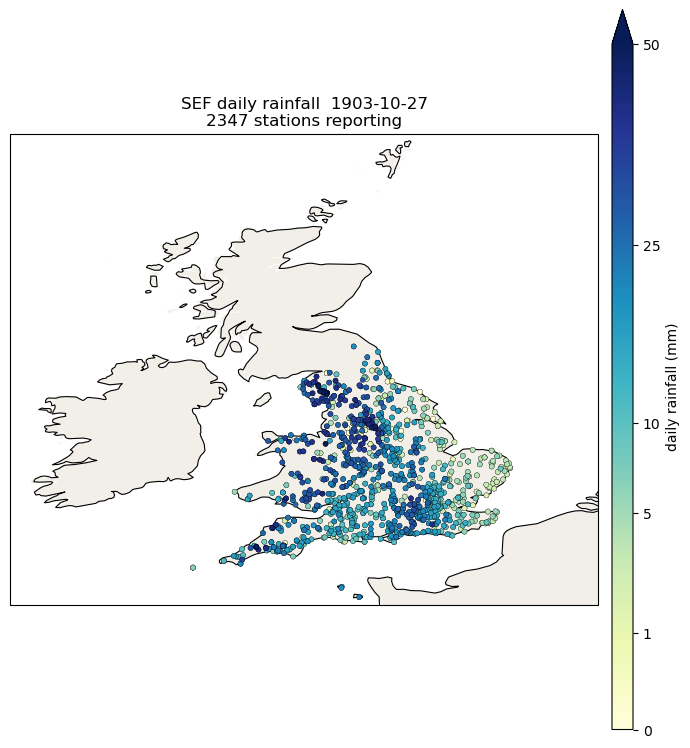

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_event_map(event_date: str, vmax: float = 50.0):
    # Map SEF daily rainfall across reporting stations for one date.
    df = q(f'''
        SELECT longitude, latitude, value_mm
        FROM read_parquet({{obs}})
        WHERE obs_date = DATE '{event_date}' AND passed AND value_mm IS NOT NULL
        ORDER BY value_mm
    ''')
    if df.empty:
        print(f"No SEF observations available for {event_date} "
              f"(is its year in the loaded dataset?)")
        return

    fig = plt.figure(figsize=(7, 9))
    ax = fig.add_axes([0.02, 0.05, 0.84, 0.9], projection=ccrs.PlateCarree())
    ax.set_extent([-11, 4, 49, 61], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#f2efe9")
    ax.coastlines(resolution="50m", linewidth=0.8, color="black")
    sc = ax.scatter(df["longitude"], df["latitude"], c=np.sqrt(df["value_mm"]),
                    cmap="YlGnBu", vmin=0, vmax=np.sqrt(vmax), s=14,
                    edgecolor="black", linewidth=0.2,
                    transform=ccrs.PlateCarree(), zorder=20)
    cax = fig.add_axes([0.88, 0.1, 0.03, 0.8])
    ticks = np.array([0, 1, 5, 10, 25, 50])
    cbar = fig.colorbar(sc, cax=cax, extend="max", ticks=np.sqrt(ticks))
    cbar.ax.set_yticklabels([str(t) for t in ticks])
    cbar.set_label("daily rainfall (mm)")
    ax.set_title(f"SEF daily rainfall  {event_date}\n{len(df)} stations reporting")
    plt.show()


# Map the first in-range event (with the demo data this is the 1903 flood).
if in_range:
    plot_event_map(in_range[0]["date"])
else:
    print("No curated events fall within the loaded years; run the full build to see event maps.")

### Next steps

Once these figures look right on the demo years, build the **full** analysis
dataset on SLURM and re-run the notebook top to bottom:

```bash
scripts/slurm/submit_sef_analysis.sh
```

The trends then span the whole SEF record and the event annotations line up with
documented floods and droughts.